# Retail Sales Data Analysis: Phase 1 & 2
**Objective:** Connect to the MySQL database, extract the raw sales data, and perform initial data cleaning (handling dates and missing values).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')


print("Connecting to MySQl...")
user = 'root'
password = 'prem2025csp'
host = 'localhost'
db_name = 'retail_sales_db'

db_url = f"mysql+pymysql://{user}:{password}@{host}/{db_name}"
engine =create_engine(db_url)

query = "SELECT * FROM sales"
df = pd.read_sql(query, engine)

print("Data loaded Successfully!")
print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns.")
df

Connecting to MySQl...
Data loaded Successfully!
Dataset shape: 9800 rows and 18 columns.


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


### Data Cleaning 


In [2]:

df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [3]:
df['Order Date']

0       08/11/2017
1       08/11/2017
2       12/06/2017
3       11/10/2016
4       11/10/2016
           ...    
9795    21/05/2017
9796    12/01/2016
9797    12/01/2016
9798    12/01/2016
9799    12/01/2016
Name: Order Date, Length: 9800, dtype: str

In [4]:
df['Ship Date']

0       11/11/2017
1       11/11/2017
2       16/06/2017
3       18/10/2016
4       18/10/2016
           ...    
9795    28/05/2017
9796    17/01/2016
9797    17/01/2016
9798    17/01/2016
9799    17/01/2016
Name: Ship Date, Length: 9800, dtype: str

In [5]:
count=df['Postal Code'].isnull().sum()
count

np.int64(11)

### Data Cleaning Strategy
Upon initial inspection, the dataset has 9,800 rows but contains two main issues:
1. **Date Formatting:** The `Order Date` and `Ship Date` are stored as text. We must convert them to `datetime` objects for time-series analysis.
2. **Missing Data:** There are 11 missing values in the `Postal Code` column. Since 11 is a negligible amount compared to 9,800 total rows, we will drop those rows to prevent geographical mapping errors later.

In [6]:
# Convert Dates to Datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

#Handling missing values 
df.dropna(subset=['Postal Code'], inplace=True)

# Dropping duplicate rows
df.drop_duplicates(inplace=True)

df.info()

<class 'pandas.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9789 non-null   int64         
 1   Order ID       9789 non-null   str           
 2   Order Date     9789 non-null   datetime64[us]
 3   Ship Date      9789 non-null   datetime64[us]
 4   Ship Mode      9789 non-null   str           
 5   Customer ID    9789 non-null   str           
 6   Customer Name  9789 non-null   str           
 7   Segment        9789 non-null   str           
 8   Country        9789 non-null   str           
 9   City           9789 non-null   str           
 10  State          9789 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9789 non-null   str           
 13  Product ID     9789 non-null   str           
 14  Category       9789 non-null   str           
 15  Sub-Category   9789 non-null   str   

## Phase 3: Exploratory Data Analysis (EDA)
In this phase, we will analyze the cleaned data to find business insights. We will use `matplotlib` and `seaborn` to visualize our findings. 

**Sales trend over time:**
We will group the sales data by month and plot it on a line chart to identify seasonal trends or spikes in revenue.


In [7]:
# Grouping the data by month and sum the sales
monthly_sales = df.set_index('Order Date').resample('MS')['Sales'].sum().reset_index()
monthly_sales

,Order Date,Sales
0,2015-01-01,14205.7070
1,2015-02-01,4519.8920
2,2015-03-01,55205.7970
3,2015-04-01,27906.8550
4,2015-05-01,23644.3030
5,2015-06-01,34322.9356
6,2015-07-01,33781.5430
7,2015-08-01,27117.5365
8,2015-09-01,81623.5268
9,2015-10-01,31453.3930


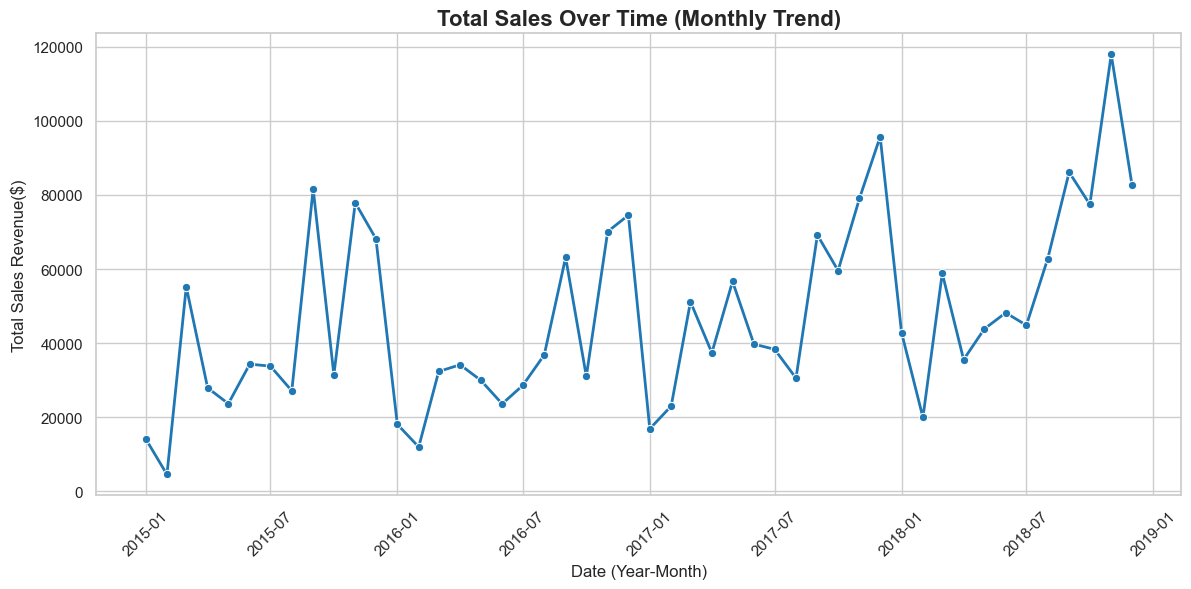

In [8]:
# Now creating the line chart
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_sales, x='Order Date', y='Sales', marker='o', color='#1f77b4', linewidth=2)

plt.title('Total Sales Over Time (Monthly Trend)', fontsize=16, fontweight='bold')
plt.xlabel('Date (Year-Month)', fontsize=12)
plt.ylabel('Total Sales Revenue($)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

**Product categories that generate the most revenue:**
 We will group the data by 'Category', calculate the total sales for each, and display it using a bar chart.

In [9]:
# Grouping data by Category and sum the sales
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
category_sales

,Category,Sales
0,Furniture,723538.4757
1,Office Supplies,703212.8240
2,Technology,825856.1130


In [10]:
# Sotring the data
category_sales = category_sales.sort_values(by='Sales', ascending=False)
category_sales

,Category,Sales
2,Technology,825856.1130
0,Furniture,723538.4757
1,Office Supplies,703212.8240


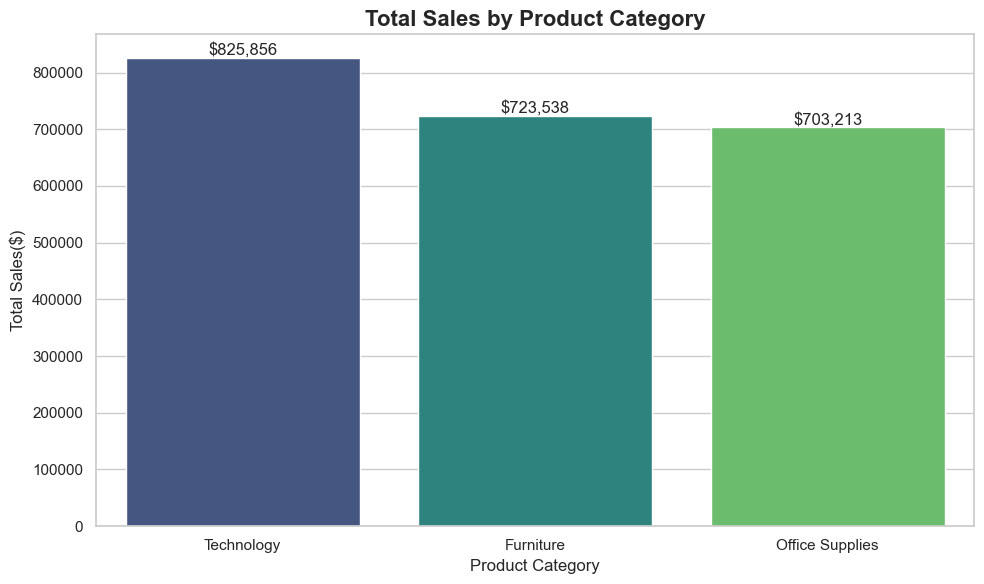

In [11]:
# Now we create bar chart to visualze this
plt.figure(figsize=(10,6))
ax = sns.barplot(data=category_sales, x='Category', y='Sales', palette='viridis')

plt.title('Total Sales by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales($)')

for label in ax.containers:
    ax.bar_label(label, fmt='${:,.0f}')

plt.tight_layout()
plt.show()

# Product Performance
**Top 10 selling Sub-Categories**
We will group the data by `Sub-Category`, sort them, and take the top 10. 

In [12]:
# Now grouping by sub-category
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().reset_index()
subcat_sales

,Sub-Category,Sales
0,Accessories,163881.6900
1,Appliances,104075.4630
2,Art,26697.3700
3,Binders,200028.7850
4,Bookcases,109408.2987
5,Chairs,322107.5310
6,Copiers,146248.0940
7,Envelopes,16126.0060
8,Fasteners,3001.9600
9,Furnishings,89212.0180


In [13]:
#Sorting the data
subcat_sales = subcat_sales.sort_values(by='Sales', ascending=False).head(10)
subcat_sales

,Sub-Category,Sales
13,Phones,326487.6980
5,Chairs,322107.5310
14,Storage,217779.1020
16,Tables,202810.6280
3,Binders,200028.7850
11,Machines,189238.6310
0,Accessories,163881.6900
6,Copiers,146248.0940
4,Bookcases,109408.2987
1,Appliances,104075.4630


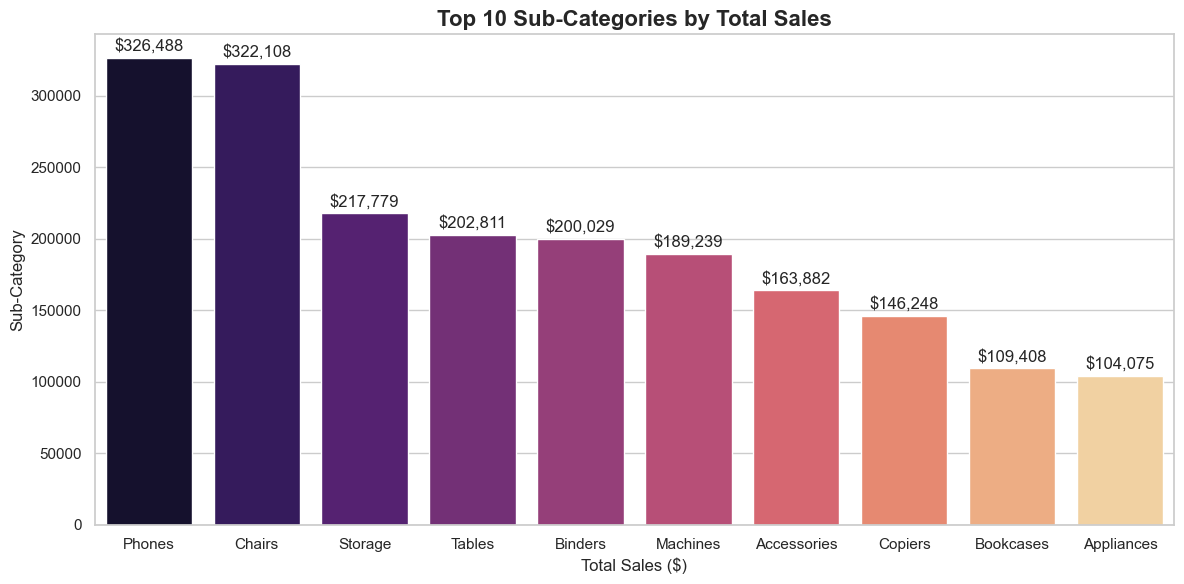

In [14]:
# Now we create bar chart to visualze this
plt.figure(figsize=(12,6))
ax = sns.barplot(data=subcat_sales, x='Sub-Category', y='Sales', palette='magma')

for label in ax.containers:
    ax.bar_label(label, fmt='${:,.0f}', padding=3)

plt.title('Top 10 Sub-Categories by Total Sales', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)

plt.tight_layout()
plt.show()

# Customer Behavior:
Who exactly is buying our products? Let's break down the total revenue by Customer Segment to see if we rely more on everyday consumers or corporate contracts.

In [15]:
#Group by Segment and sum the sales
segment_sales = df.groupby('Segment')['Sales'].sum().reset_index()
segment_sales = segment_sales.sort_values(by='Sales', ascending=False)
segment_sales

,Segment,Sales
0,Consumer,1.146708e+06
1,Corporate,6.822118e+05
2,Home Office,4.236874e+05


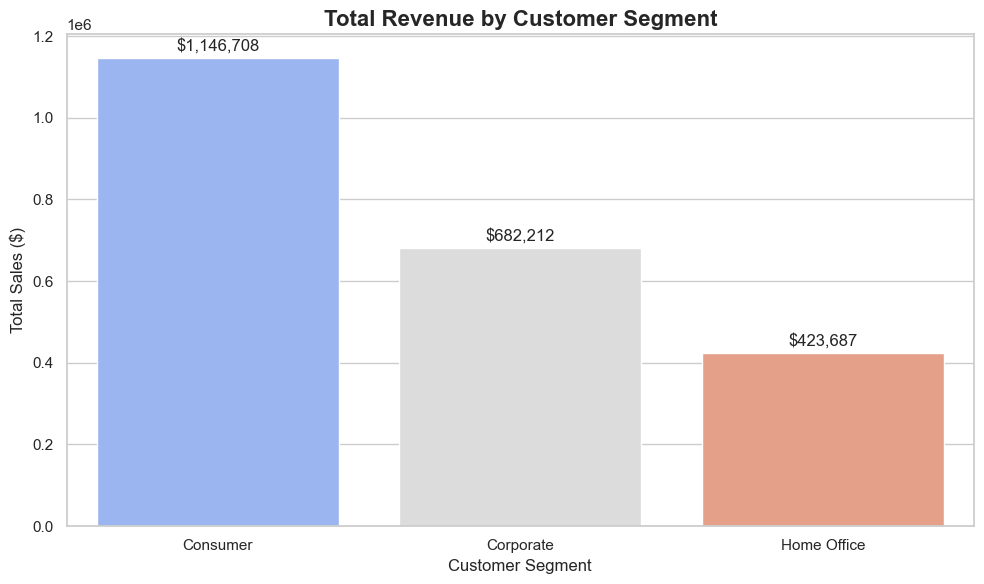

In [16]:
# Create the Bar Chart
plt.figure(figsize=(10, 6))
ax_seg = sns.barplot(data=segment_sales, x='Segment', y='Sales', palette='coolwarm')

plt.title('Total Revenue by Customer Segment', fontsize=16, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

for label in ax_seg.containers:
    ax_seg.bar_label(label, fmt='${:,.0f}', padding=3)

plt.tight_layout()
plt.show()

# Geographical Performance: 
We will aggregate total sales by `Region` and visualize the percentage breakdown using a Donut Chart to understand our strongest and weakest markets.

In [17]:
# Grouping by Region and sum the sales
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
region_sales

,Region,Sales
0,Central,492646.9132
1,East,660589.3560
2,South,389151.4590
3,West,710219.6845


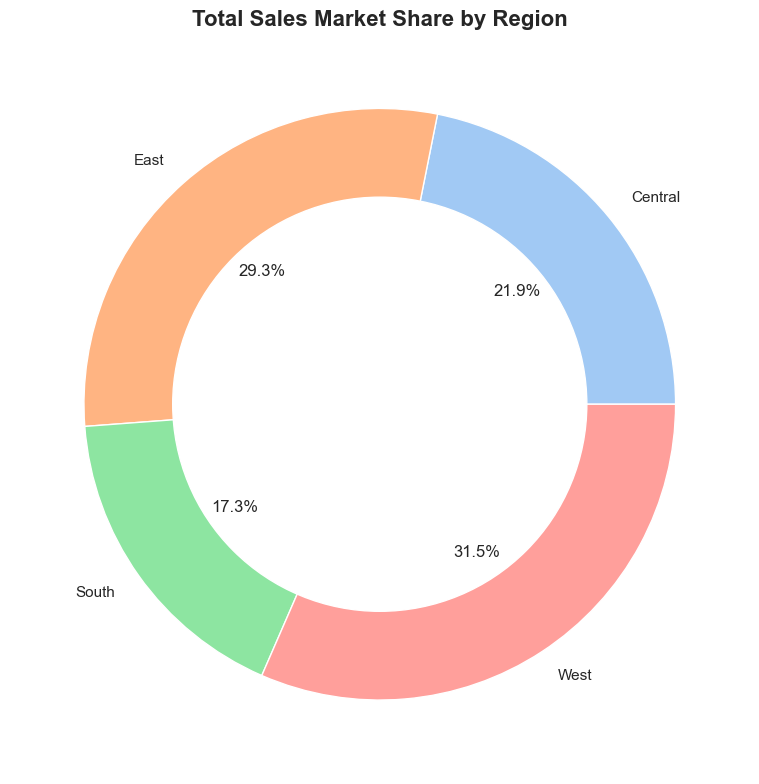

In [18]:
# Now displaying this in chart 
plt.figure(figsize=(8,8))
colors = sns.color_palette('pastel')[0:len(region_sales)]

plt.pie(region_sales['Sales'], labels=region_sales['Region'], colors=colors,autopct='%1.1f%%',wedgeprops={'width': 0.5})
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Total Sales Market Share by Region', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()